<div style="display: inline-block; vertical-align: top; margin-right: 10px;">
  <img src="../Fig/Lasso_project_1.png" alt="Lasso Project Figure" width="400">
</div>

<div style="display: inline-block; vertical-align: top;">
  <img src="../Fig/ridge.png" alt="Ridge Project Figure" width="400">
</div>


Bsed on the result from the project 1 and our current code structure we have decided to test Adam setup for different L1 and L2 norms and parameters.

Lasso parameterst for test to compare with l1:

degree - 3, lambda 0.1, learning rate 0.05

test mse: 0.03858

Ridge to comapre with L2:

degree 6, lambda 0, learning rate 0.01

test mse: 0.0146


In [1]:
import matplotlib.pyplot as plt
import autograd.numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
import warnings
import autograd.numpy as np  
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

from functions import (
    cost,create_layers_batch,  feed_forward_batch, feed_forward_saver_batch,
    backpropagation_batch, polynomial_features, plot_accuracy, plot_MSE_to_Iter, print_output, calculate_nlayer_nn
)
from activations import (
    sigmoid, ReLU, leaky_ReLu, sigmoid_der, ReLU_der, leaky_ReLU_der, softmax, softmax_der
)
from costs import (
    mse, mse_der, cross_entropy, binary_cross_entropy_loss,
    binary_cross_entropy_loss_l1, binary_cross_entropy_loss_l2,
    multiclass_cross_entropy_loss, crossentropy_der,mse_l2, mse_l1, mse_l2_der, mse_l1_der
)
from train_funct import (
    train_network, train_network_SGD_momentum, train_network_RMSprop, train_network_ADAM
)  

In [3]:
# Setting seed for reproducibility
np.random.seed(42)
n = 200

# Creating a grid of n=200 points drawn from the random distribution
x = np.random.uniform(-1, 1, n)

# Setting up Runge's function, 1 normal and 1 with added noise
y = 1.0 / (1 + 25 * x**2) + np.random.normal(0, 0.1, x.shape)

# Calculating sample statistics
x_mean = np.mean(x)
x_variance = np.std(x, ddof=1) #sample variance

#Scaling x values for a visual comparison
x_st = (x - x_mean) / x_variance

# Now we split the dataset for training and testing (using the standardized x values) and noisy Runge
X_train, X_test, y_train, y_test = train_test_split(x_st, y, test_size=0.2, random_state = 42)


## Part e): Testing different norms

Finally, still using the one-dimensional Runge function, add now the hyperparameters $\\lambda$ with the $\\L_2$ and $\\L_1$ norms. Find the optimal results for the hyperparameters $\\lambda$ and the learning rates $\\eta$ and neural network architecture and compare the $\\L_2$ results with Ridge regression from project 1 and the $\\L_1$ results with the Lasso calculations of project 1.Use again the same data sets and the best results from project 1 in your comparisons.

In [4]:
def train_network_ADAM_l_norm(
    _inputs, _layers, activation_funcs, targets, activation_ders,
    learning_rate=0.001, beta1=0.9, beta2=0.999, eps=1e-8, epochs=30,
    grad_tol=1e-6, verbose=False, cost_der=mse_der, reg = 'l1', lambda_l=0.0
):
    """
    Adam optimizer + L1/L2 regularization (set in backprop).
    Early stop when ||grad||_2 <= grad_tol.
    """
    predictions = []
    m = [(np.zeros_like(W), np.zeros_like(b)) for W, b in _layers]
    v = [(np.zeros_like(W), np.zeros_like(b)) for W, b in _layers]

    t = 0
    stopped_at = None

    for e in range(epochs):
        t += 1

        # NEW: regularized backpropagation
        layers_grad = backpropagation_batch_with_norms(
            _inputs, _layers, activation_funcs, targets, activation_ders,
            cost_der, lambda_l, reg   # <--- L1 or L2 used here
        )

        # Early stop on global gradient norm
        grad_sq_sum = sum(np.sum(gW**2) + np.sum(gb**2) for gW, gb in layers_grad)
        grad_norm = np.sqrt(grad_sq_sum)
        if grad_norm <= grad_tol:
            if verbose:
                print(f"[Adam] Early stop at epoch {e+1}: ||grad||={grad_norm:.3e} ≤ {grad_tol:.3e}")
            stopped_at = e + 1
            prediction = feed_forward_batch(_inputs, _layers, activation_funcs)
            predictions.append(prediction)
            break

        # Standard Adam update
        layers_updated = []
        for j, ((W, b), (gW, gb)) in enumerate(zip(_layers, layers_grad)):
            mW, mb = m[j]
            vW, vb = v[j]

            mW = beta1 * mW + (1.0 - beta1) * gW
            mb = beta1 * mb + (1.0 - beta1) * gb

            vW = beta2 * vW + (1.0 - beta2) * (gW * gW)
            vb = beta2 * vb + (1.0 - beta2) * (gb * gb)

            mW_hat = mW / (1.0 - beta1 ** t)
            mb_hat = mb / (1.0 - beta1 ** t)
            vW_hat = vW / (1.0 - beta2 ** t)
            vb_hat = vb / (1.0 - beta2 ** t)

            W = W - learning_rate * mW_hat / (np.sqrt(vW_hat) + eps)
            b = b - learning_rate * mb_hat / (np.sqrt(vb_hat) + eps)

            m[j] = (mW, mb)
            v[j] = (vW, vb)
            layers_updated.append((W, b))

        _layers = layers_updated
        prediction = feed_forward_batch(_inputs, _layers, activation_funcs)
        predictions.append(prediction)

    if stopped_at is not None and stopped_at < epochs:
        last_pred = predictions[-1]
        predictions.extend([last_pred] * (epochs - stopped_at))

    last_prediction = predictions[-1]
    return predictions, last_prediction, layers_updated


In [5]:
#for mse_l1 and mse_l2-----
def backpropagation_batch_with_norms(inputs, layers, activation_funcs, target, activation_ders, 
                                     cost_der, lambda_l = 0.0, reg = None):
    layer_inputs, zs, predict = feed_forward_saver_batch(inputs, layers, activation_funcs)
    layer_grads = [() for _ in layers]

    for i in reversed(range(len(layers))):
        layer_input, z, activation_der = layer_inputs[i], zs[i], activation_ders[i]

        if i == len(layers) - 1:
            """ An optional L1 or L2 norm of the weights and biases 
            in the cost function (only used for computing gradients, not interpretable metrics)"""
            #dC_da, reg_term = cost_der(predict, target, W_i, lambda_l)
            dC_da = cost_der(predict, target)

        else:
            (W, b) = layers[i + 1]
            dC_da = dC_dz @ W.T
        dC_dz = dC_da * activation_der(z)
        dC_dW = np.matmul(layer_input.T, dC_dz) / target.shape[0]
        dC_db = np.mean(dC_dz, axis=0)

     # Regularization on current layer weights only
        W_i, _ = layers[i]
        if reg == 'l2':
            dC_dW += 2.0 * lambda_l * W_i
        elif reg == 'l1':
            dC_dW += lambda_l * np.sign(W_i)   # subgradient; sign(0)=0
        layer_grads[i] = (dC_dW, dC_db)
    return layer_grads


In [6]:
def calculate_nlayer_nn_l1_l2(inputs_train, 
                              targets_train,
                              inputs_test, 
                              targets_test, 
                              n_iter,
                              learning_rates, 
                              network_input_size, 
                              layer_output_sizes, 
                              activation_funcs, 
                              activation_ders, 
                              reg='l1',
                              lambda_l=0.01,
                              mse_type=None,        # interpretable metric (default: mse)
                              mse_der_type=None):   # d/dy_pred at output (default: mse_der)
    # defaults
    if mse_type is None:
        mse_type = mse
    if mse_der_type is None:
        mse_der_type = mse_der

    results = []          # (lr, train_mse, test_mse)
    histories = {}        # lr -> [(epoch_idx, train_mse_at_epoch), ...]

    for lr in learning_rates:
        # Fresh init for each LR
        layers = create_layers_batch(network_input_size, layer_output_sizes)

        # Train with Adam + chosen regularization
        predictions, last_pred, trained_layers = train_network_ADAM_l_norm(
            _inputs=inputs_train,
            _layers=layers,
            activation_funcs=activation_funcs,
            targets=targets_train,
            activation_ders=activation_ders,
            learning_rate=lr,
            epochs=n_iter,
            cost_der=mse_der_type,   # derivative wrt predictions at output
            reg=reg,
            lambda_l=lambda_l
        )

        # Interpretable metrics (no regularization term)
        train_mse = mse_type(last_pred, targets_train)
        test_pred = feed_forward_batch(inputs_test, trained_layers, activation_funcs)
        test_mse  = mse_type(test_pred, targets_test)

        # History length may be < n_iter if early-stopped
        histories[lr] = [[i, mse_type(p, targets_train)] for i, p in enumerate(predictions)]

        results.append((lr, float(train_mse), float(test_mse)))

    return results, histories


# Results from project 1

Lasso parameterst for test to compare with l1:

degree - 3, lambda 0.1, learning rate 0.05

test mse: 0.03858

## ADAM

In [40]:
# ---- Grid over learning rates ----
poly_degree = 3
inputs_train = np.array(polynomial_features(X_train, poly_degree))
targets_train = y_train.reshape(-1, 1)

inputs_test = np.array(polynomial_features(X_test, poly_degree))
targets_test = y_test.reshape(-1, 1)

network_input_size = poly_degree + 1

## L1
### 1 layer

In [23]:
lambda_values = [0.1, 0.01, 0.001, 0.0001]
all_results = {}
all_histories = {}

for lam in lambda_values:
    print(f"\n=== Running Adam with L1 regularization, λ = {lam} ===")
    
    results, histories_best = calculate_nlayer_nn_l1_l2(
        inputs_train=inputs_train, 
        targets_train=targets_train,
        inputs_test=inputs_test, 
        targets_test=targets_test, 
        n_iter=1000,
        learning_rates=[1e-4, 1e-3, 1e-2, 0.05, 1e-1],
        network_input_size=network_input_size,
        layer_output_sizes=[50, 1],
        activation_funcs=[sigmoid, ReLU],
        activation_ders=[sigmoid_der, ReLU_der],
        reg='l1',                 # or 'l2'
        lambda_l=lam,
        mse_type=mse,             # interpretable metric
        mse_der_type=mse_der      # derivative wrt predictions at output
    )

    all_results[lam] = results
    all_histories[lam] = histories_best

    print_output(results, gd_type=f'ADAM L1 (λ={lam})')



=== Running Adam with L1 regularization, λ = 0.1 ===

=== Learning rate summary ADAM L1 (λ=0.1) ===
lr=0.0001    train MSE=0.241275  test MSE=0.255175
lr=0.001     train MSE=0.160468  test MSE=0.116423
lr=0.01      train MSE=0.160468  test MSE=0.116423
lr=0.1       train MSE=0.160468  test MSE=0.116423
lr=0.05      train MSE=0.160468  test MSE=0.116423

=== Running Adam with L1 regularization, λ = 0.01 ===

=== Learning rate summary ADAM L1 (λ=0.01) ===
lr=0.0001    train MSE=0.301335  test MSE=0.321823
lr=0.001     train MSE=0.155914  test MSE=0.113662
lr=0.01      train MSE=0.160468  test MSE=0.116423
lr=0.1       train MSE=0.160468  test MSE=0.116423
lr=0.05      train MSE=0.160468  test MSE=0.116423

=== Running Adam with L1 regularization, λ = 0.001 ===

=== Learning rate summary ADAM L1 (λ=0.001) ===
lr=0.0001    train MSE=0.155132  test MSE=0.150963
lr=0.001     train MSE=0.102597  test MSE=0.080345
lr=0.01      train MSE=0.090849  test MSE=0.057515
lr=0.1       train MSE=0.160

OLS Lasso from project 1 with parameters degree - 3, lambda 0.1, learning rate 0.05 have best test mse: 0.03858


From our code with 1 layer, degree - 3, learning rate 0.05:

when lambda 0.1 our mse test MSE=0.060590

the best mse is 

=== Learning rate summary ADAM L1 (λ=0.0001) ===

lr=0.05      train MSE=0.065327  test MSE=0.040002

### 2 layers

In [24]:
lambda_values = [0.1, 0.01, 0.001, 0.0001]
all_results = {}
all_histories = {}

for lam in lambda_values:
    print(f"\n=== Running Adam with L1 regularization, λ = {lam} ===")

    results, histories_best = calculate_nlayer_nn_l1_l2(
        inputs_train=inputs_train, 
        targets_train=targets_train,
        inputs_test=inputs_test, 
        targets_test=targets_test, 
        n_iter=1000,
        learning_rates=[1e-4, 1e-3, 1e-2, 0.05, 1e-1],
        network_input_size=network_input_size,
        layer_output_sizes=[100, 100, 1],
        activation_funcs=[sigmoid, sigmoid, ReLU],
        activation_ders=[sigmoid_der, sigmoid_der, ReLU_der],
        reg='l1',                 # or 'l2'
        lambda_l=lam,             # <— iterated value
        mse_type=mse,             # interpretable metric
        mse_der_type=mse_der      # derivative wrt predictions
    )

    all_results[lam] = results
    all_histories[lam] = histories_best

    print_output(results, gd_type=f'ADAM L1 (λ={lam})')



=== Running Adam with L1 regularization, λ = 0.1 ===

=== Learning rate summary ADAM L1 (λ=0.1) ===
lr=0.0001    train MSE=0.160468  test MSE=0.116423
lr=0.001     train MSE=0.160468  test MSE=0.116423
lr=0.01      train MSE=0.160468  test MSE=0.116423
lr=0.05      train MSE=0.160468  test MSE=0.116423
lr=0.1       train MSE=0.160468  test MSE=0.116423

=== Running Adam with L1 regularization, λ = 0.01 ===

=== Learning rate summary ADAM L1 (λ=0.01) ===
lr=0.0001    train MSE=0.160468  test MSE=0.116423
lr=0.001     train MSE=0.160468  test MSE=0.116423
lr=0.01      train MSE=0.160468  test MSE=0.116423
lr=0.05      train MSE=0.160468  test MSE=0.116423
lr=0.1       train MSE=0.160468  test MSE=0.116423

=== Running Adam with L1 regularization, λ = 0.001 ===

=== Learning rate summary ADAM L1 (λ=0.001) ===
lr=0.0001    train MSE=0.160468  test MSE=0.116423
lr=0.001     train MSE=0.160468  test MSE=0.116423
lr=0.01      train MSE=0.160468  test MSE=0.116423
lr=0.05      train MSE=0.160

OLS Lasso from project 1 with parameters degree - 3, lambda 0.1, learning rate 0.05 have best test mse: 0.03858

From our code with 2 layer, degree - 3, learning rate 0.05:

when lambda 0.1 our mse test MSE=0.116423


for L1 OLS have better MSE in comparison wiht  1 or 2 layers NN

when we use different degree, for example 7 we obtain better test MSE results 

=== Learning rate summary ADAM L1 (λ=0.0001) ===

lr=0.001     train MSE=0.017689  test MSE=0.017928

what was best for OSL does not perform the same for NN

## ADAM L2


In [35]:
# ---- Grid over learning rates ----
poly_degree = 6
inputs_train = np.array(polynomial_features(X_train, poly_degree))
targets_train = y_train.reshape(-1, 1)

inputs_test = np.array(polynomial_features(X_test, poly_degree))
targets_test = y_test.reshape(-1, 1)

network_input_size = poly_degree + 1

# Results from project 1

Ridge to comapre with L2:

degree 6, lambda 0, learning rate 0.01

test mse: 0.0146

### 1 layer

In [37]:
lambda_values = [0.1, 0.01, 0.001, 0.0001]
all_results = {}
all_histories = {}

for lam in lambda_values:
    print(f"\n=== Running Adam with L2 regularization, λ = {lam} ===")
    
    results, histories_best = calculate_nlayer_nn_l1_l2(
        inputs_train=inputs_train, 
        targets_train=targets_train,
        inputs_test=inputs_test, 
        targets_test=targets_test, 
        n_iter=1000,
        learning_rates=[1e-4, 1e-3, 1e-2, 1e-1], # 0.01
        network_input_size=network_input_size,
        layer_output_sizes=[50, 1],
        activation_funcs=[sigmoid, ReLU],
        activation_ders=[sigmoid_der, ReLU_der],
        reg='l2',                 # or 'l2'
        lambda_l=lam,
        mse_type=mse,             # interpretable metric
        mse_der_type=mse_der      # derivative wrt predictions at output
    )

    all_results[lam] = results
    all_histories[lam] = histories_best

    print_output(results, gd_type=f'ADAM L2 (λ={lam})')



=== Running Adam with L2 regularization, λ = 0.1 ===

=== Learning rate summary ADAM L2 (λ=0.1) ===
lr=0.0001    train MSE=0.411441  test MSE=0.286709
lr=0.001     train MSE=0.160468  test MSE=0.116423
lr=0.01      train MSE=0.160468  test MSE=0.116423
lr=0.1       train MSE=0.090745  test MSE=0.057841

=== Running Adam with L2 regularization, λ = 0.01 ===

=== Learning rate summary ADAM L2 (λ=0.01) ===
lr=0.0001    train MSE=0.368117  test MSE=0.255133
lr=0.001     train MSE=0.160468  test MSE=0.116423
lr=0.01      train MSE=0.160468  test MSE=0.116423
lr=0.1       train MSE=0.090745  test MSE=0.057841

=== Running Adam with L2 regularization, λ = 0.001 ===

=== Learning rate summary ADAM L2 (λ=0.001) ===
lr=0.0001    train MSE=0.187567  test MSE=0.129814
lr=0.001     train MSE=0.160468  test MSE=0.116423
lr=0.01      train MSE=0.160468  test MSE=0.116423
lr=0.1       train MSE=0.085879  test MSE=0.053505

=== Running Adam with L2 regularization, λ = 0.0001 ===

=== Learning rate sum

### 2 layers

In [38]:
lambda_values = [0.1, 0.01, 0.001, 0.0001]
all_results = {}
all_histories = {}

for lam in lambda_values:
    print(f"\n=== Running Adam with L2 regularization, λ = {lam} ===")

    results, histories_best = calculate_nlayer_nn_l1_l2(
        inputs_train=inputs_train, 
        targets_train=targets_train,
        inputs_test=inputs_test, 
        targets_test=targets_test, 
        n_iter=1000,
        learning_rates=[1e-4, 1e-3, 1e-2, 1e-1],
        network_input_size=network_input_size,
        layer_output_sizes=[100, 100, 1],
        activation_funcs=[sigmoid, sigmoid, ReLU],
        activation_ders=[sigmoid_der, sigmoid_der, ReLU_der],
        reg='l2',                 # or 'l2'
        lambda_l=lam,             # <— iterated value
        mse_type=mse,             # interpretable metric
        mse_der_type=mse_der      # derivative wrt predictions
    )

    all_results[lam] = results
    all_histories[lam] = histories_best

    print_output(results, gd_type=f'ADAM L2 (λ={lam})')



=== Running Adam with L2 regularization, λ = 0.1 ===

=== Learning rate summary ADAM L2 (λ=0.1) ===
lr=0.0001    train MSE=0.160468  test MSE=0.116423
lr=0.001     train MSE=0.160468  test MSE=0.116423
lr=0.01      train MSE=0.160468  test MSE=0.116423
lr=0.1       train MSE=0.160468  test MSE=0.116423

=== Running Adam with L2 regularization, λ = 0.01 ===

=== Learning rate summary ADAM L2 (λ=0.01) ===
lr=0.0001    train MSE=0.160468  test MSE=0.116423
lr=0.001     train MSE=0.160468  test MSE=0.116423
lr=0.01      train MSE=0.160468  test MSE=0.116423
lr=0.1       train MSE=0.160468  test MSE=0.116423

=== Running Adam with L2 regularization, λ = 0.001 ===

=== Learning rate summary ADAM L2 (λ=0.001) ===
lr=0.0001    train MSE=0.160468  test MSE=0.116423
lr=0.001     train MSE=0.160468  test MSE=0.116423
lr=0.01      train MSE=0.160468  test MSE=0.116423
lr=0.1       train MSE=0.160468  test MSE=0.116423

=== Running Adam with L2 regularization, λ = 0.0001 ===

=== Learning rate sum

# Fig generation for raport


=== Running Adam with L1 regularization, λ = 0.1 ===

=== Learning rate summary ADAM L2 (λ=0.1) ===
lr=0.0001    train MSE=0.177129  test MSE=0.161787
lr=0.001     train MSE=0.097044  test MSE=0.063875
lr=0.01      train MSE=0.090746  test MSE=0.057821
lr=0.1       train MSE=0.090735  test MSE=0.057843

=== Running Adam with L1 regularization, λ = 0.01 ===

=== Learning rate summary ADAM L2 (λ=0.01) ===
lr=0.0001    train MSE=0.177636  test MSE=0.162344
lr=0.001     train MSE=0.096691  test MSE=0.063647
lr=0.01      train MSE=0.090748  test MSE=0.057776
lr=0.1       train MSE=0.090966  test MSE=0.058664

=== Running Adam with L1 regularization, λ = 0.001 ===

=== Learning rate summary ADAM L2 (λ=0.001) ===
lr=0.0001    train MSE=0.183656  test MSE=0.168922
lr=0.001     train MSE=0.095693  test MSE=0.064041
lr=0.01      train MSE=0.090751  test MSE=0.057748
lr=0.1       train MSE=0.090912  test MSE=0.057448

=== Running Adam with L1 regularization, λ = 0.0001 ===

=== Learning rate sum

/var/folders/2x/86b82jhn7m5cwtv2m75stgq80000gn/T/ipykernel_47368/1619559903.py:50: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(train_df.applymap(lambda v: f"{v:.4e}"))
/var/folders/2x/86b82jhn7m5cwtv2m75stgq80000gn/T/ipykernel_47368/1619559903.py:53: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(test_df.applymap(lambda v: f"{v:.4e}"))


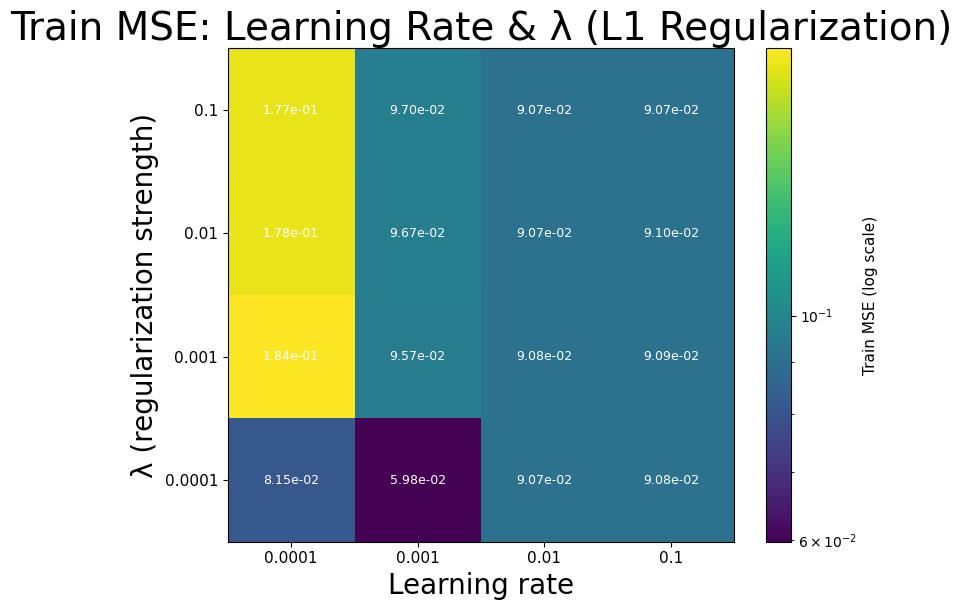

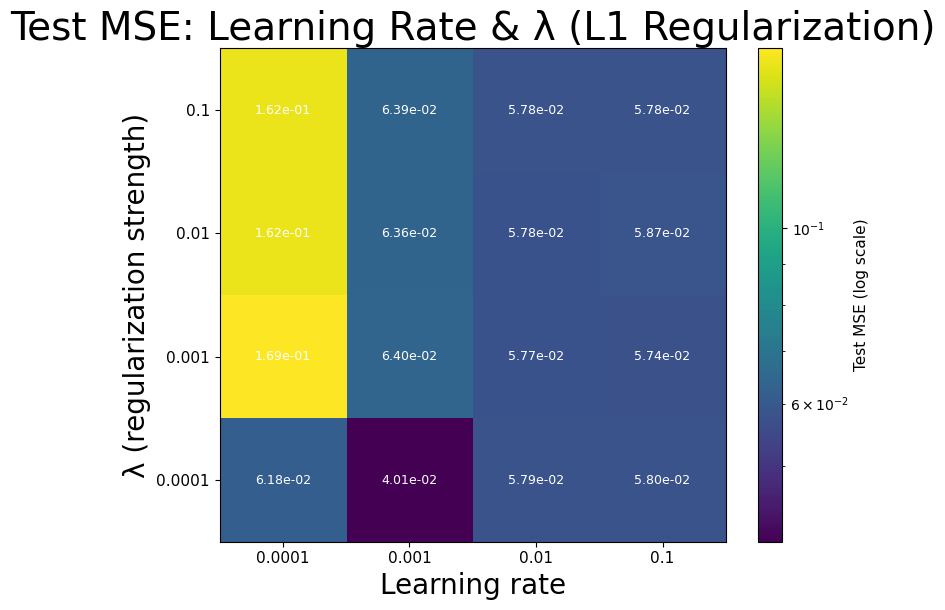

In [42]:
# --- Parameter grids ---
lambda_values  = [0.1, 0.01, 0.001, 0.0001]     # rows
learning_rates = [1e-4, 1e-3, 1e-2, 1e-1]       # cols

# --- Storage ---
train_mse_mat = np.zeros((len(lambda_values), len(learning_rates)), dtype=float)
test_mse_mat  = np.zeros((len(lambda_values), len(learning_rates)), dtype=float)

all_results   = {}
all_histories = {}

# --- Run experiments ---
for i, lam in enumerate(lambda_values):
    print(f"\n=== Running Adam with L1 regularization, λ = {lam} ===")

    # This function evaluates over multiple learning rates
    results, histories_best = calculate_nlayer_nn_l1_l2(
        inputs_train=inputs_train, 
        targets_train=targets_train,
        inputs_test=inputs_test, 
        targets_test=targets_test, 
        n_iter=1000,
        learning_rates=learning_rates,
        network_input_size=network_input_size,
        layer_output_sizes=[50, 1],
        activation_funcs=[sigmoid, sigmoid, ReLU],
        activation_ders=[sigmoid_der, sigmoid_der, ReLU_der],
        reg='l1',                  # using L2 regularization
        lambda_l=lam,              # iterated lambda
        mse_type=mse,
        mse_der_type=mse_der
    )

    # Store results
    all_results[lam] = results
    all_histories[lam] = histories_best

    # results likely looks like: [(lr, train_mse, test_mse), ...]
    for j, (lr, tr_mse, te_mse) in enumerate(results):
        train_mse_mat[i, j] = float(tr_mse)
        test_mse_mat[i, j]  = float(te_mse)

    print_output(results, gd_type=f'ADAM L2 (λ={lam})')

# ---- DataFrames for readability ----
train_df = pd.DataFrame(train_mse_mat, index=lambda_values, columns=learning_rates)
test_df  = pd.DataFrame(test_mse_mat,  index=lambda_values, columns=learning_rates)

print("\n=== Train MSE (rows=λ, cols=learning rate) ===")
print(train_df.applymap(lambda v: f"{v:.4e}"))

print("\n=== Test  MSE (rows=λ, cols=learning rate) ===")
print(test_df.applymap(lambda v: f"{v:.4e}"))

# ---- Heatmap helper ----
from matplotlib.colors import LogNorm

def plot_heatmap(data, title, x_labels, y_labels, cbar_label="MSE", use_log=True):
    fig, ax = plt.subplots(figsize=(1.2*len(x_labels)+3, 0.8*len(y_labels)+3))
    if use_log:
        vmin = max(float(np.min(data)), 1e-12)
        im = ax.imshow(data, aspect='auto', cmap='viridis', norm=LogNorm(vmin=vmin, vmax=float(np.max(data))))
    else:
        im = ax.imshow(data, aspect='auto', cmap='viridis')

    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, fontsize=11)
    ax.set_yticks(range(len(y_labels)))
    ax.set_yticklabels(y_labels, fontsize=11)
    ax.set_xlabel('Learning rate', fontsize=20)
    ax.set_ylabel('λ (regularization strength)', fontsize=20)
    ax.set_title(title, fontsize=28)

    # annotate cells with MSE values
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            ax.text(c, r, f"{data[r, c]:.2e}", ha='center', va='center', color='white', fontsize=9)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(f"{cbar_label}" + (" (log scale)" if use_log else ""), fontsize=11)
    plt.tight_layout()
    plt.show()

# ---- Plot TRAIN MSE heatmap ----
plot_heatmap(
    train_mse_mat,
    title="Train MSE: Learning Rate & λ (L1 Regularization)",
    x_labels=learning_rates,
    y_labels=lambda_values,
    cbar_label="Train MSE",
    use_log=True
)

# ---- Optionally, also plot TEST MSE heatmap ----
plot_heatmap(
    test_mse_mat,
    title="Test MSE: Learning Rate & λ (L1 Regularization)",
    x_labels=learning_rates,
    y_labels=lambda_values,
    cbar_label="Test MSE",
    use_log=True
)
